<a href="https://colab.research.google.com/github/rafaelrdealmeida/fundamentos_2026_lantri01/blob/main/notebooks/encontro_2026_lantri_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução ao Pensamento computacional

## Ferramentas/Serviços utilizados

- Google Colab (notebook com codigo)
- Github (rede social de código)
- Git (programa de versionamento de código)


## Pilares
- Decomposição
- Abstração
- Identificação de padrões
- Lógica


## Noções Gerais

- Exemplos a partir de coleta de dados
  - Site MRE - Notas de imprensa
    - [x] Link do site: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa
    - [x] Entender a estrutura da fonte de informação
    - [ ] Realizar a coleta
    - [ ] Inserir as informações em um banco de dados
    - [ ] Utilizar as informações (analise de dados)


### Padrão de paginação das notas de imprensa
  - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=0
   - https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=30
   - Pagina final (10/02/2026): 6210



## Importação de bibliotecas/pogramas utilizados neste arquivo

In [1]:
!pip install tinydb

In [2]:
# programas/bibliotecas utilizados no script/codigo
import httpx # Responsável pelas requisições web
from bs4 import BeautifulSoup # Responsável por realizar o web scraping (coletar os dados)
from tinydb import TinyDB, Query

## Criação do banco json

In [3]:
def inserir_no_banco(dados, link_noticia):
  arquivo_banco_dados = "nota_mre.json"
  db = TinyDB(arquivo_banco_dados)


  # Evitar dados repetidos no banco
  Buscar = Query()
  verificar_link = db.contains(Buscar.link == link_noticia)

  if not verificar_link:
    print("Inserindo nova informação no banco")
    db.insert(dados)
  else:
    print("Link já existe no banco. Esta informação não será inserida novamente")

In [4]:
# Variável e tipos de dados (string, lista, numero)
paginas = ["https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=0"]

def acessa_pagina (link):
  print (f"Estamos na pagina:{link}")

  # Define headers para a requisição, simulando um navegador
  headers = {
      'User-Agent': "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36",
      'Accept-Language': 'en-US,en;q=0.9',
      'Accept-Encoding': 'gzip, deflate, br',
      'Connection': 'keep-alive',
  }

  timeout = httpx.Timeout(connect=20.0, read=30.0, write=20.0, pool=10.0)
  pag_web = httpx.get(link, headers=headers, timeout=timeout)
  bs = BeautifulSoup(pag_web, "html.parser")
  return bs

# loop for
# beautifulsoap >> find e find_all

for pagina in paginas:
  pagina_inteira = acessa_pagina(pagina)
  lista_noticias = pagina_inteira.find("div", attrs={"id": "content-core"}).find_all("article")
  for noticia in lista_noticias:
    # titulo
    try:
      titulo = noticia.find("h2", attrs={"class": "tileHeadline"}).text.strip()
      print(titulo)
    except:
        titulo = ""

    #link
    try:
      link_noticia = noticia.a["href"]
      print(link_noticia)
    except:
      link_noticia = ""
    # numero da nota - exemplo: NOTA À IMPRENSA Nº 72
    # numero da nota - exemplo: NOTA À IMPRENSA N° 590
    num_nota = noticia.find("span", attrs={"class": "subtitle"}).text.strip()
    # print(num_nota)
    # num_nota = noticia.find(attrs={"class": "subtitle"}).text.strip()
    num_nota = num_nota.replace("NOTA À IMPRENSA N°", "").replace("NOTA À IMPRENSA Nº", "").strip()
    print(num_nota)
    print("###")
    # data
    # horário
    data_hora = noticia.find_all("span",attrs={"class": "summary-view-icon"})
    data= data_hora[0].text.strip()
    hora = data_hora[1].text.strip()
    print(data)
    print(hora)
    conteudo = acessa_pagina (link_noticia)
    paragrafos = conteudo.find("div", attrs={"property":"rnews:articleBody"}).find_all("p")
    lista_paragrafos = []
    for paragrafo in paragrafos:
      lista_paragrafos.append(paragrafo.text.strip())
    print(lista_paragrafos)
    # função para inserir dados coletados no banco
    dados = {
        "titulo": titulo,
        "link": link_noticia,
        "data": data,
        "hora": hora,
        "num_nota": num_nota,
        "paragrafo": lista_paragrafos
    }
    inserir_no_banco(dados,link_noticia)






Estamos na pagina:https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/notas-a-imprensa?b_start:int=0
Redução dos valores cobrados de passaportes emitidos no exterior
https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/reducao-dos-valores-cobrados-de-passaportes-emitidos-no-exterior
154
###
04/05/2026
17h15
Estamos na pagina:https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/reducao-dos-valores-cobrados-de-passaportes-emitidos-no-exterior
['A partir de 1º de junho de 2026, os valores cobrados em moeda estrangeira para a emissão de passaportes brasileiros nas embaixadas e consulados do Brasil no exterior serão reduzidos pela metade, aproximando-os dos valores cobrados no Brasil.', 'A medida, formalizada pela Portaria MRE nº 664/2026, visa a contribuir para a manutenção da documentação brasileira em dia por parte de indivíduos e famílias binacionais no exterior, em especial de crianças nascidas fora do Brasil.', 'O passapo

# Transformar banco json e dataframe

- pre-analise - entendimento geral sobre o dataframe

In [5]:
import pandas as pd
import json

## Abrindo o rquivo json
with open("nota_mre.json") as f:
  raw = json.load(f)

df = pd.DataFrame.from_dict(raw["_default"], orient="index")

df


,titulo,link,data,hora,num_nota,paragrafo
1,Redução dos valores cobrados de passaportes em...,https://www.gov.br/mre/pt-br/canais_atendiment...,04/05/2026,17h15,154,"[A partir de 1º de junho de 2026, os valores c..."
2,IX Rodada Negociadora MERCOSUL-Canadá - Nota C...,https://www.gov.br/mre/pt-br/canais_atendiment...,01/05/2026,19h00,153,"[Realizou-se, entre os dias 27 e 30 de abril, ..."
3,Nota Conjunta Brasil-Espanha sobre sequestro e...,https://www.gov.br/mre/pt-br/canais_atendiment...,01/05/2026,12h00,152,"[Os governos do Brasil e da Espanha condenam, ..."
4,Declaração Conjunta sobre os Ataques Israelens...,https://www.gov.br/mre/pt-br/canais_atendiment...,30/04/2026,20h57,NOTA À IMPRENSA N. 151,"[., Declaração Conjunta dos Ministros das Rela..."
5,Abertura de mercado para o Brasil no Chile - N...,https://www.gov.br/mre/pt-br/canais_atendiment...,29/04/2026,17h49,150,[O governo brasileiro concluiu negociações que...
6,Promulgação do Acordo Provisório de Comércio e...,https://www.gov.br/mre/pt-br/canais_atendiment...,28/04/2026,19h20,149,[O Presidente Luiz Inácio Lula da Silva assino...
7,Mortes de brasileiros no Líbano em decorrência...,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,19h04,148,"[O governo brasileiro tomou conhecimento, com ..."
8,Ataques terroristas no Mali,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,13h38,147,[O Governo brasileiro manifesta grave preocupa...
9,Atentado na Colômbia,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,08h45,146,[O governo brasileiro condena o ataque perpetr...
10,Apresentação da candidatura do Professor Georg...,https://www.gov.br/mre/pt-br/canais_atendiment...,24/04/2026,15h57,145,"[Realizou-se, em 23 de abril, coquetel de apre..."


In [6]:
# saber quantidade de linhas e colunas do dataframe
df.shape

(30, 6)

In [7]:
# saber colunas disponiveis
df.columns

Index(['titulo', 'link', 'data', 'hora', 'num_nota', 'paragrafo'], dtype='object')

In [8]:
# selecionar uma coluna em especifico
df["titulo"]

,titulo
1,Redução dos valores cobrados de passaportes em...
2,IX Rodada Negociadora MERCOSUL-Canadá - Nota C...
3,Nota Conjunta Brasil-Espanha sobre sequestro e...
4,Declaração Conjunta sobre os Ataques Israelens...
5,Abertura de mercado para o Brasil no Chile - N...
6,Promulgação do Acordo Provisório de Comércio e...
7,Mortes de brasileiros no Líbano em decorrência...
8,Ataques terroristas no Mali
9,Atentado na Colômbia
10,Apresentação da candidatura do Professor Georg...


In [9]:

# delimitar colunas do dataframe
df_delimitado = df[["titulo", "data"]]
df_delimitado

,titulo,data
1,Redução dos valores cobrados de passaportes em...,04/05/2026
2,IX Rodada Negociadora MERCOSUL-Canadá - Nota C...,01/05/2026
3,Nota Conjunta Brasil-Espanha sobre sequestro e...,01/05/2026
4,Declaração Conjunta sobre os Ataques Israelens...,30/04/2026
5,Abertura de mercado para o Brasil no Chile - N...,29/04/2026
6,Promulgação do Acordo Provisório de Comércio e...,28/04/2026
7,Mortes de brasileiros no Líbano em decorrência...,27/04/2026
8,Ataques terroristas no Mali,27/04/2026
9,Atentado na Colômbia,27/04/2026
10,Apresentação da candidatura do Professor Georg...,24/04/2026


In [10]:

# primeiras (head), ultimas (tail) e linhas aleatórias (sample)
df.head(10)

,titulo,link,data,hora,num_nota,paragrafo
1,Redução dos valores cobrados de passaportes em...,https://www.gov.br/mre/pt-br/canais_atendiment...,04/05/2026,17h15,154,"[A partir de 1º de junho de 2026, os valores c..."
2,IX Rodada Negociadora MERCOSUL-Canadá - Nota C...,https://www.gov.br/mre/pt-br/canais_atendiment...,01/05/2026,19h00,153,"[Realizou-se, entre os dias 27 e 30 de abril, ..."
3,Nota Conjunta Brasil-Espanha sobre sequestro e...,https://www.gov.br/mre/pt-br/canais_atendiment...,01/05/2026,12h00,152,"[Os governos do Brasil e da Espanha condenam, ..."
4,Declaração Conjunta sobre os Ataques Israelens...,https://www.gov.br/mre/pt-br/canais_atendiment...,30/04/2026,20h57,NOTA À IMPRENSA N. 151,"[., Declaração Conjunta dos Ministros das Rela..."
5,Abertura de mercado para o Brasil no Chile - N...,https://www.gov.br/mre/pt-br/canais_atendiment...,29/04/2026,17h49,150,[O governo brasileiro concluiu negociações que...
6,Promulgação do Acordo Provisório de Comércio e...,https://www.gov.br/mre/pt-br/canais_atendiment...,28/04/2026,19h20,149,[O Presidente Luiz Inácio Lula da Silva assino...
7,Mortes de brasileiros no Líbano em decorrência...,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,19h04,148,"[O governo brasileiro tomou conhecimento, com ..."
8,Ataques terroristas no Mali,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,13h38,147,[O Governo brasileiro manifesta grave preocupa...
9,Atentado na Colômbia,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,08h45,146,[O governo brasileiro condena o ataque perpetr...
10,Apresentação da candidatura do Professor Georg...,https://www.gov.br/mre/pt-br/canais_atendiment...,24/04/2026,15h57,145,"[Realizou-se, em 23 de abril, coquetel de apre..."


In [11]:
df.describe(include="all")

,titulo,link,data,hora,num_nota,paragrafo
count,30,30,30,30,30,30
unique,30,30,16,28,30,30
top,Redução dos valores cobrados de passaportes em...,https://www.gov.br/mre/pt-br/canais_atendiment...,17/04/2026,19h20,154,"[A partir de 1º de junho de 2026, os valores c..."
freq,1,1,4,2,1,1


In [12]:
df.isnull().sum()

,0
titulo,0
link,0
data,0
hora,0
num_nota,0
paragrafo,0


### Tratamento de Dados e Visualização

Agora que entendemos a estrutura, vamos preparar os dados para extrair insights visuais. Um passo comum é converter colunas de texto em formatos que o computador entenda como 'tempo' (datetime) e criar gráficos.

In [15]:
# 1. Converter a coluna de data para o formato datetime do Pandas
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True)

# 2. Contar quantas notícias temos por dia
noticias_por_dia = df['data_dt'].value_counts().sort_index()

display(noticias_por_dia)

,count
data_dt,
2026-04-12,1
2026-04-14,2
2026-04-15,3
2026-04-16,2
2026-04-17,4
2026-04-18,2
2026-04-19,1
2026-04-20,3
2026-04-22,1


#### Visualizando o Volume de Publicações

Vamos usar a biblioteca `matplotlib` (que já vem no ambiente) para criar um gráfico de barras simples.

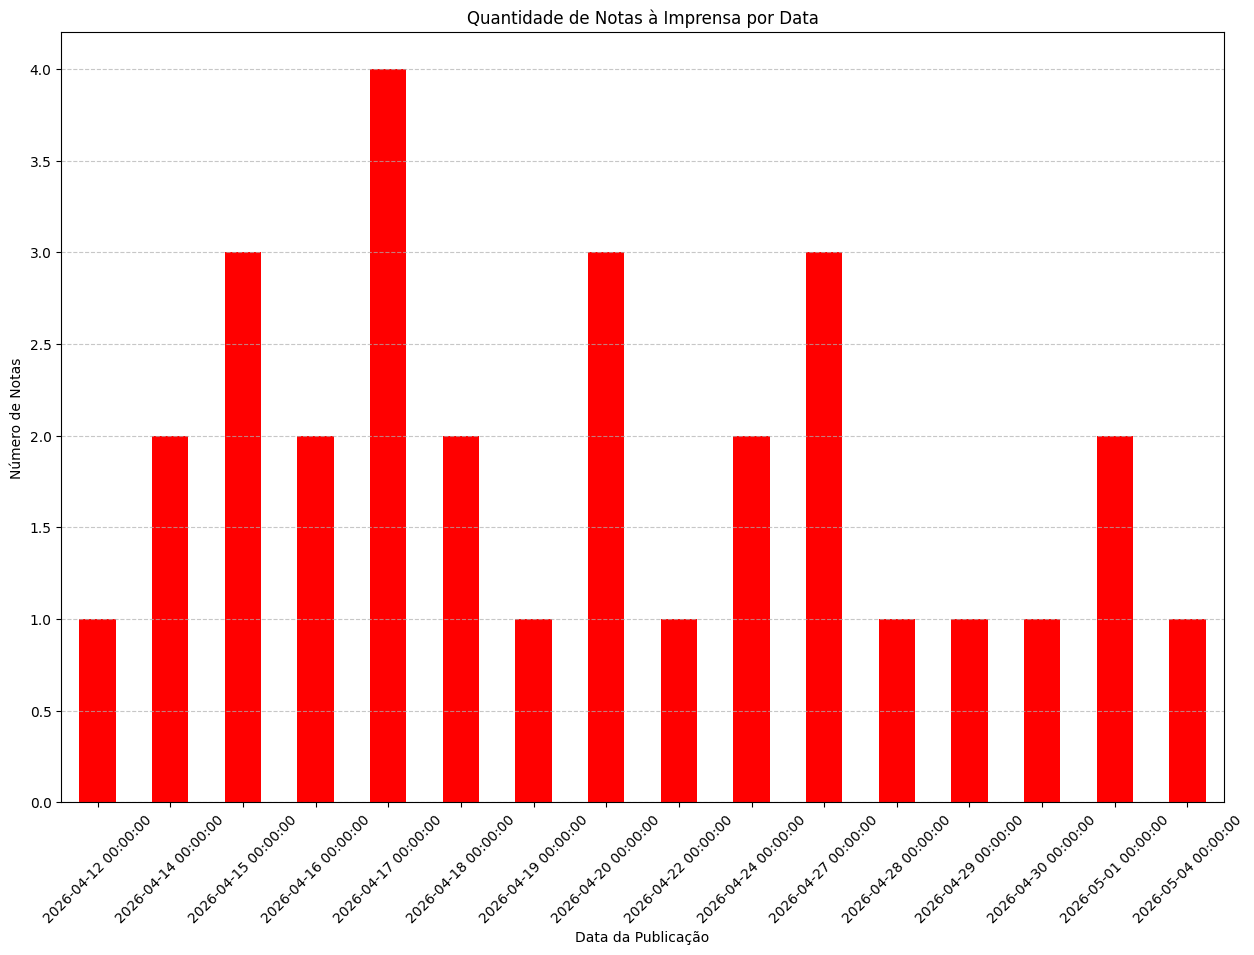

In [40]:
import matplotlib.pyplot as plt

# Criando o gráfico
plt.figure(figsize=(15, 10))
noticias_por_dia.plot(kind='bar', color='red')

# Adicionando títulos e rótulos
plt.title('Quantidade de Notas à Imprensa por Data')
plt.xlabel('Data da Publicação')
plt.ylabel('Número de Notas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Analisando Palavras-Chave nos Títulos

Uma técnica simples de análise de texto para iniciantes é verificar a frequência de certas palavras-chave (como nomes de países).

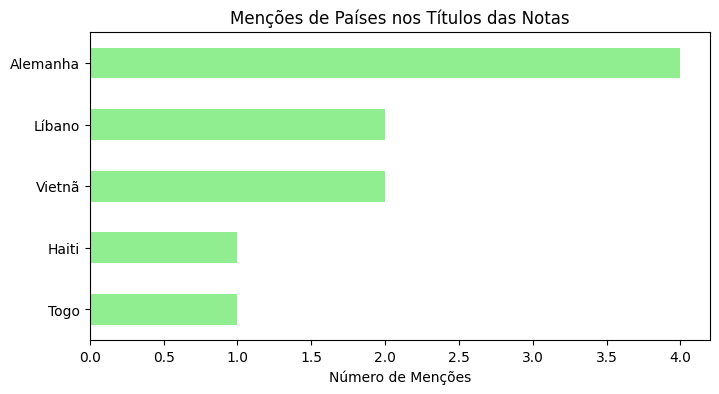

In [41]:
paises = ['Alemanha', 'Líbano', 'Vietnã', 'Togo', 'Haiti']
frequencia = {}

for pais in paises:
    # Conta em quantos títulos a palavra aparece
    frequencia[pais] = df['titulo'].str.contains(pais, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções de Países nos Títulos das Notas')
plt.xlabel('Número de Menções')
plt.show()

---

# 📊 Visualização avançada dos dados

Nesta parte vamos:

1. **Preparar** os dados (corrigir tipos, criar colunas auxiliares)
2. **Buscar** por termos e palavras-chave (no título e no corpo da nota)
3. **Analisar** frequência de termos (países, temas, organizações)
4. **Visualizar** o volume de publicações no tempo
5. **Acompanhar** um tema específico ao longo do tempo
6. **Gerar** nuvens de palavras (word cloud)
7. **Examinar** o tamanho das notas
8. **Descobrir** co-ocorrências (quais países aparecem juntos)


## 1. Preparação dos dados

Antes de visualizar, precisamos arrumar algumas coisas:

- A coluna `data` está como **texto** (`"22/04/2026"`). Vamos transformar em **datetime** para conseguir agrupar por mês, dia da semana, etc.
- A coluna `paragrafo` contém **listas** de strings — por isso `df.duplicated()` deu erro mais acima. Vamos juntar os parágrafos em um único texto na coluna `texto`.
- Vamos criar uma coluna `texto_completo` com título + corpo, em minúsculas, para facilitar buscas case-insensitive.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafo'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.4 — Extrair a hora como número inteiro (de "19h20" tira o 19)
df['hora_int'] = df['hora'].str.extract(r'(\d{1,2})').astype(float)

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafo'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de notas: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'hora_int', 'qtd_paragrafos', 'tamanho_texto']].head()


Total de notas: 30
Período: de 2026-04-12 até 2026-05-04


,titulo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
1,Redução dos valores cobrados de passaportes em...,2026-05-04,17.0,3,768
2,IX Rodada Negociadora MERCOSUL-Canadá - Nota C...,2026-05-01,19.0,4,874
3,Nota Conjunta Brasil-Espanha sobre sequestro e...,2026-05-01,12.0,4,838
4,Declaração Conjunta sobre os Ataques Israelens...,2026-04-30,20.0,12,2846
5,Abertura de mercado para o Brasil no Chile - N...,2026-04-29,17.0,5,716


### 1.1 Verificar duplicatas

Como a coluna `paragrafo` é uma lista, ela quebra o `df.duplicated()`. Solução: verificar duplicatas só nas colunas que importam (link, título).


In [19]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df.duplicated(subset=['titulo']).sum())


Duplicatas por link: 0
Duplicatas por título: 0


## 2. 🔍 Busca por termos e palavras-chave

A busca anterior só olhava o **título**. Vamos criar uma função que busca no **título e/ou no corpo** da nota, mostrando quantas notas mencionam o termo e permitindo ver os resultados.


In [20]:
def buscar_termo(termo, onde='completo', mostrar=5):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)
        mostrar (int): quantos resultados imprimir

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df)} ({len(resultado)/len(df)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.head(mostrar).iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    if len(resultado) > mostrar:
        print(f"  ... e mais {len(resultado) - mostrar} nota(s)")

    return resultado


# Exemplos de uso:
res = buscar_termo('Líbano', onde='completo', mostrar=5)


🔎 Termo: 'Líbano'  |  Onde: completo
📌 Notas encontradas: 2 de 30 (6.7%)
------------------------------------------------------------
  • [27/04/2026] Mortes de brasileiros no Líbano em decorrência de ataques israelenses
  • [17/04/2026] Cessar-fogo no Líbano


In [21]:
# Buscar só no título
buscar_termo('mercado', onde='titulo', mostrar=5)


🔎 Termo: 'mercado'  |  Onde: titulo
📌 Notas encontradas: 6 de 30 (20.0%)
------------------------------------------------------------
  • [29/04/2026] Abertura de mercado para o Brasil no Chile - Nota Conjunta MRE/MAPA
  • [24/04/2026] Aberturas de mercado para o Brasil em Cuba, nas Filipinas e na Coreia do Sul
  • [22/04/2026] Aberturas de mercado para o Brasil no Togo - Nota Conjunta MRE/MAPA
  • [17/04/2026] Abertura de mercado para o Brasil no Vietnã - Nota Conjunta MRE/MAPA
  • [15/04/2026] Aberturas de mercado para o Brasil na Arábia Saudita, no Azerbaijão, em El Salvador, na Jordânia e na Etiópia - Nota Conjunta MRE/MAPA
  ... e mais 1 nota(s)


,titulo,link,data,hora,num_nota,paragrafo,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
5,Abertura de mercado para o Brasil no Chile - N...,https://www.gov.br/mre/pt-br/canais_atendiment...,29/04/2026,17h49,150,[O governo brasileiro concluiu negociações que...,2026-04-29,O governo brasileiro concluiu negociações que ...,abertura de mercado para o brasil no chile - n...,17.0,2026-04,Wednesday,716,5
11,"Aberturas de mercado para o Brasil em Cuba, na...",https://www.gov.br/mre/pt-br/canais_atendiment...,24/04/2026,15h48,144,[O governo brasileiro concluiu negociações que...,2026-04-24,O governo brasileiro concluiu negociações que ...,"aberturas de mercado para o brasil em cuba, na...",15.0,2026-04,Friday,1105,6
12,Aberturas de mercado para o Brasil no Togo - N...,https://www.gov.br/mre/pt-br/canais_atendiment...,22/04/2026,19h20,143,[O governo brasileiro concluiu negociações que...,2026-04-22,O governo brasileiro concluiu negociações que ...,aberturas de mercado para o brasil no togo - n...,19.0,2026-04,Wednesday,671,1
20,Abertura de mercado para o Brasil no Vietnã - ...,https://www.gov.br/mre/pt-br/canais_atendiment...,17/04/2026,12h31,135,[O governo brasileiro concluiu negociações com...,2026-04-17,O governo brasileiro concluiu negociações com ...,abertura de mercado para o brasil no vietnã - ...,12.0,2026-04,Friday,759,1
26,Aberturas de mercado para o Brasil na Arábia S...,https://www.gov.br/mre/pt-br/canais_atendiment...,15/04/2026,18h30,129,[O governo brasileiro concluiu negociações que...,2026-04-15,O governo brasileiro concluiu negociações que ...,aberturas de mercado para o brasil na arábia s...,18.0,2026-04,Wednesday,1357,1
29,"Aberturas de mercado para o Brasil no Vietnã, ...",https://www.gov.br/mre/pt-br/canais_atendiment...,14/04/2026,20h10,126,[O governo brasileiro concluiu negociações que...,2026-04-14,O governo brasileiro concluiu negociações que ...,"aberturas de mercado para o brasil no vietnã, ...",20.0,2026-04,Tuesday,1155,1


In [23]:
# Buscar uma expressão composta
buscar_termo('cessar-fogo', onde='completo', mostrar=5)


🔎 Termo: 'cessar-fogo'  |  Onde: completo
📌 Notas encontradas: 2 de 30 (6.7%)
------------------------------------------------------------
  • [27/04/2026] Mortes de brasileiros no Líbano em decorrência de ataques israelenses
  • [17/04/2026] Cessar-fogo no Líbano


,titulo,link,data,hora,num_nota,paragrafo,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
7,Mortes de brasileiros no Líbano em decorrência...,https://www.gov.br/mre/pt-br/canais_atendiment...,27/04/2026,19h04,148,"[O governo brasileiro tomou conhecimento, com ...",2026-04-27,"O governo brasileiro tomou conhecimento, com c...",mortes de brasileiros no líbano em decorrência...,19.0,2026-04,Monday,1721,5
19,Cessar-fogo no Líbano,https://www.gov.br/mre/pt-br/canais_atendiment...,17/04/2026,15h23,136,[O governo brasileiro saúda o anúncio de cessa...,2026-04-17,O governo brasileiro saúda o anúncio de cessar...,cessar-fogo no líbano o governo brasileiro saú...,15.0,2026-04,Friday,876,3


## 3. 📈 Frequência de vários termos comparados

Vamos generalizar a análise: em vez de fixar 5 países, comparamos qualquer lista de termos de interesse (países, organizações, temas) — buscando no texto **completo** (não só no título).


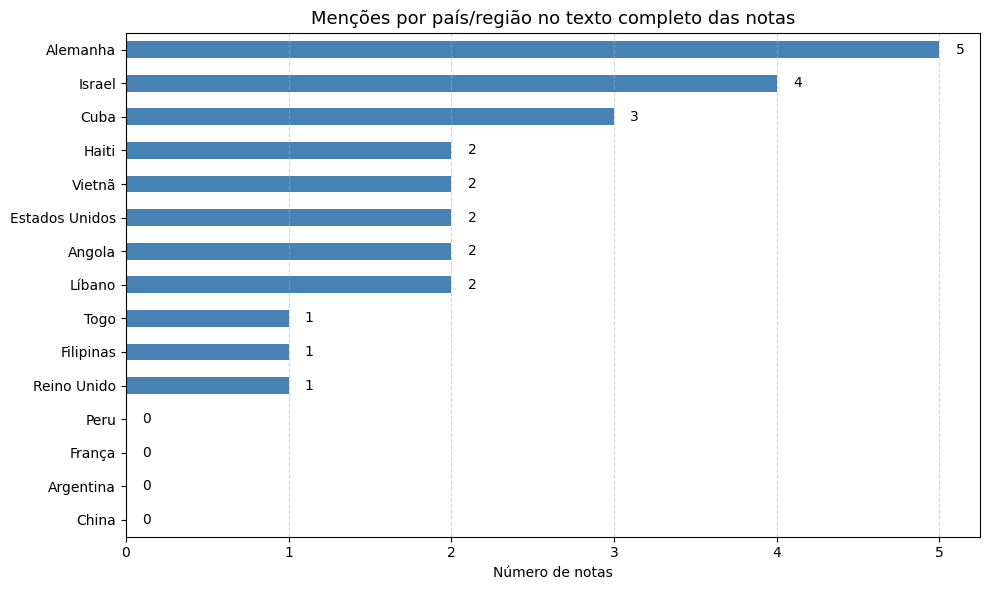

In [24]:
def frequencia_termos(lista_termos, onde='completo'):
    """Conta em quantas notas cada termo da lista aparece."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    freq = {}
    for termo in lista_termos:
        freq[termo] = df[coluna].str.contains(termo, case=False, na=False, regex=False).sum()
    return pd.Series(freq).sort_values(ascending=True)


# Lista mais ampla de países e temas
termos_interesse = [
    'Alemanha', 'Líbano', 'Vietnã', 'Togo', 'Haiti',
    'Argentina', 'China', 'Estados Unidos', 'Israel', 'Cuba',
    'Angola', 'Peru', 'Filipinas', 'Reino Unido', 'França'
]

freq = frequencia_termos(termos_interesse, onde='completo')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
freq.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Menções por país/região no texto completo das notas', fontsize=13)
ax.set_xlabel('Número de notas')
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Anotar valores nas barras
for i, valor in enumerate(freq.values):
    ax.text(valor + 0.1, i, str(valor), va='center')

plt.tight_layout()
plt.show()


## 4. 🧠 Extração automática de palavras mais frequentes

Em vez de **definirmos** os termos, deixamos os dados falarem: quais palavras aparecem mais nos títulos? Para isso precisamos remover as **stopwords** (palavras muito comuns como "de", "da", "para") e palavras curtas.


Top 20 palavras nos TÍTULOS:
  conjunta                  14
  brasil                    11
  mapa                      7
  abril                     7
  declaração                6
  mercado                   6
  visita                    5
  presidente                5
  espanha                   4
  ataques                   4
  aberturas                 4
  alemanha                  4
  ocasião                   3
  hannover                  3
  barcelona                 3
  oficial                   3
  senhor                    3
  república                 3
  mercosul                  2
  mdic                      2


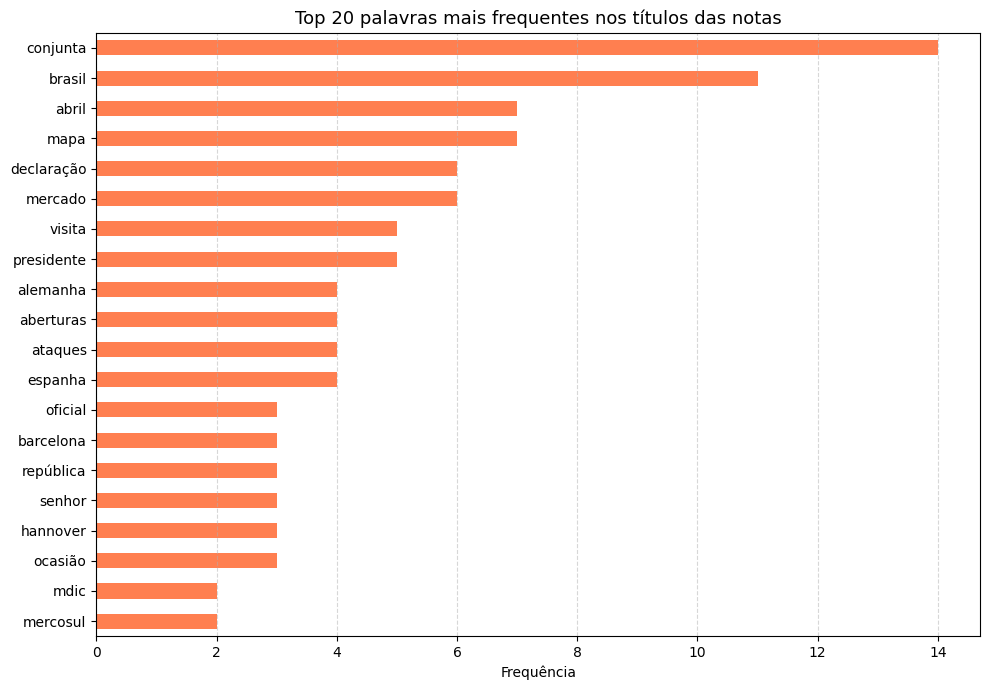

In [25]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa',  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. 🗓️ Análise temporal

O gráfico anterior ("notas por dia") fica difícil de ler quando há muitas datas. Vamos olhar em **agregações** mais úteis: por mês, por dia da semana, e por hora do dia.


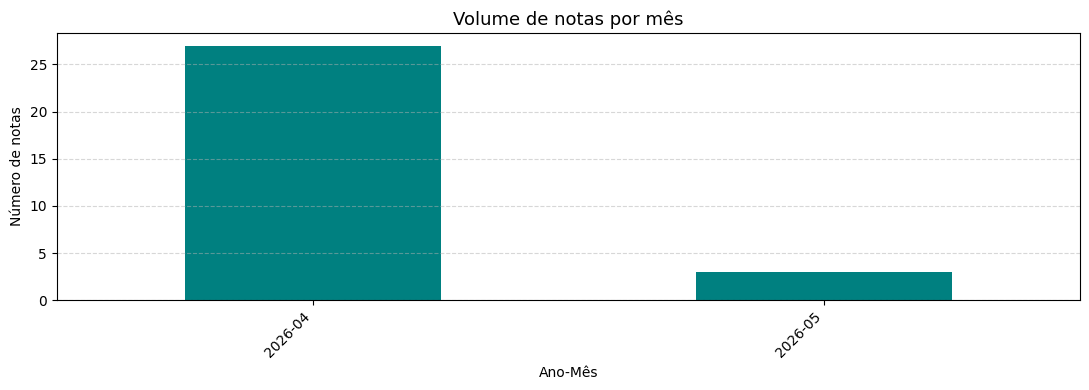

In [26]:
# Notas por mês
notas_por_mes = df.groupby('ano_mes').size()

fig, ax = plt.subplots(figsize=(11, 4))
notas_por_mes.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Volume de notas por mês', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


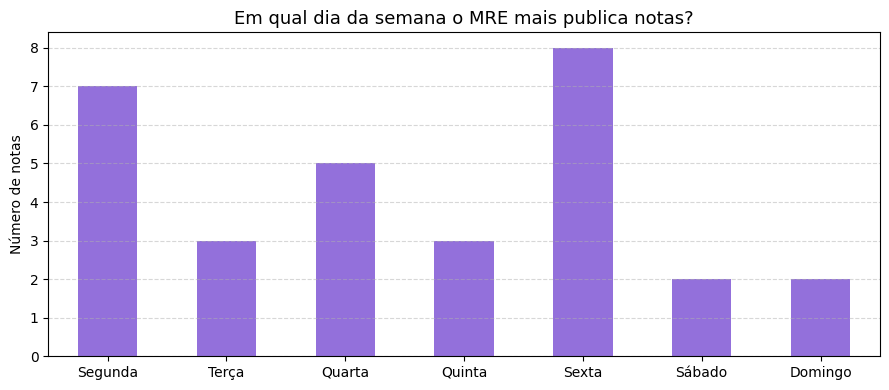

In [27]:
# Notas por dia da semana (em português)
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traducao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

por_dia_semana = df['dia_semana'].value_counts().reindex(ordem_dias).fillna(0)
por_dia_semana.index = [traducao_dias[d] for d in por_dia_semana.index]

fig, ax = plt.subplots(figsize=(9, 4))
por_dia_semana.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Em qual dia da semana o MRE mais publica notas?', fontsize=13)
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


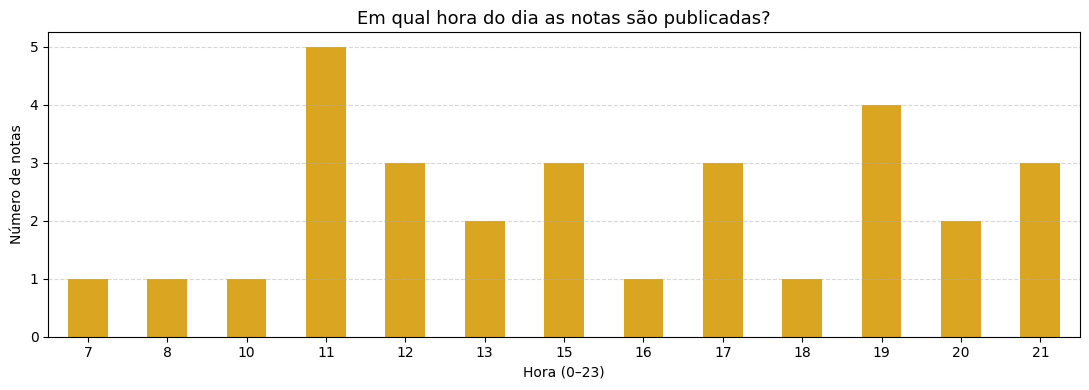

In [28]:
# Notas por hora do dia
por_hora = df['hora_int'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
por_hora.plot(kind='bar', ax=ax, color='goldenrod')
ax.set_title('Em qual hora do dia as notas são publicadas?', fontsize=13)
ax.set_xlabel('Hora (0–23)')
ax.set_ylabel('Número de notas')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. 📅 Acompanhar um tema ao longo do tempo

Combinando busca por termo + análise temporal: como evoluiu a menção a um país ou tema ao longo dos meses?


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


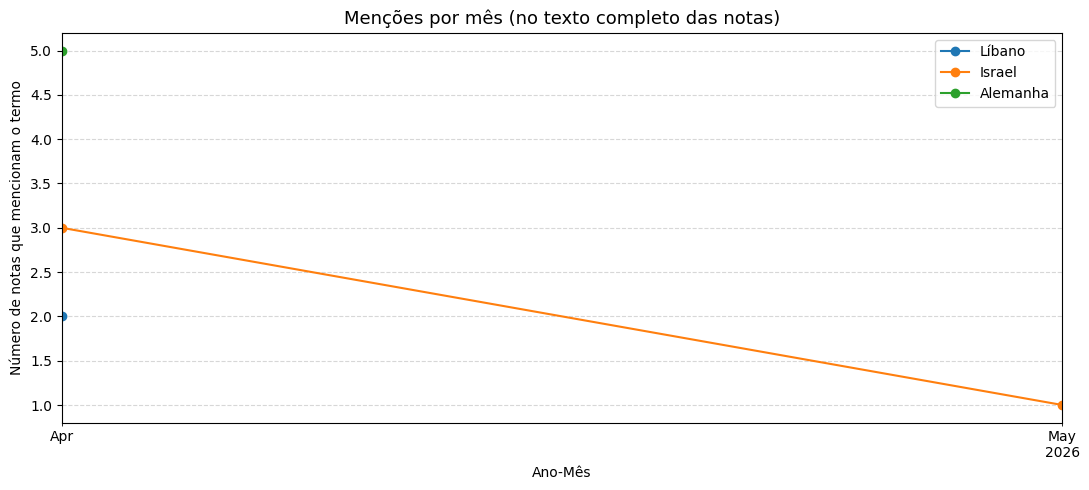

In [29]:
def evolucao_termo(termo, onde='completo'):
    """Mostra quantas notas mencionam o termo por mês."""
    coluna = {'titulo': 'titulo', 'texto': 'texto', 'completo': 'texto_completo'}[onde]
    mascara = df[coluna].str.contains(termo, case=False, na=False, regex=False)
    return df[mascara].groupby('ano_mes').size()


# Comparar evolução de vários termos no tempo
termos_comparar = ['Líbano', 'Israel', 'Alemanha', 'Argentina']

fig, ax = plt.subplots(figsize=(11, 5))
for termo in termos_comparar:
    serie = evolucao_termo(termo)
    if len(serie) > 0:
        serie.plot(ax=ax, marker='o', label=termo)

ax.set_title('Menções por mês (no texto completo das notas)', fontsize=13)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de notas que mencionam o termo')
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. ☁️ Nuvem de palavras (word cloud)

Forma visual e divertida de ver os termos mais frequentes — quanto maior a palavra, mais ela aparece.

> ⚠️ Precisa instalar a biblioteca `wordcloud` (rode a próxima célula uma vez).


In [30]:
!pip install wordcloud -q


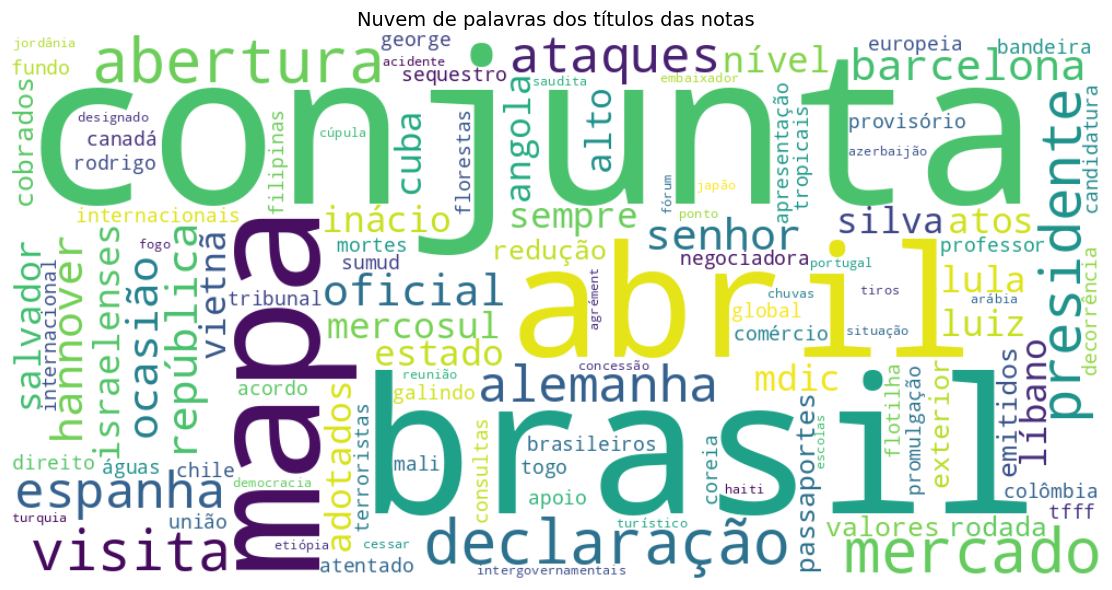

In [31]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()


## 8. 📏 Tamanho das notas

Quanto texto o MRE costuma escrever em cada nota? Algumas notas são bem curtas (ex: cumprimentos), outras são longas (declarações conjuntas, etc.).


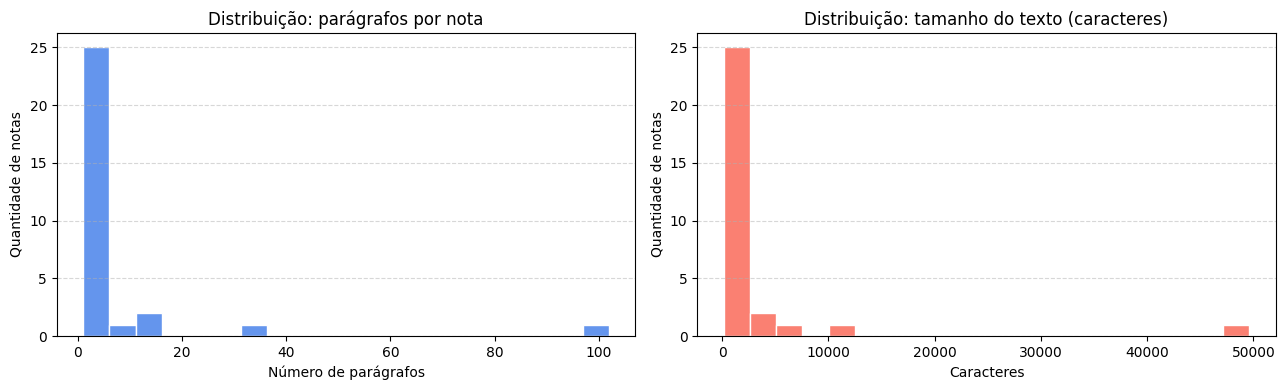


📊 Estatísticas:
       qtd_paragrafos  tamanho_texto
count            30.0           30.0
mean              8.1         3224.0
std              18.9         9064.5
min               1.0          146.0
25%               1.2          726.8
50%               3.0          926.0
75%               5.0         1399.0
max             102.0        49619.0


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de quantidade de parágrafos
df['qtd_paragrafos'].plot(kind='hist', bins=20, ax=axes[0], color='cornflowerblue', edgecolor='white')
axes[0].set_title('Distribuição: parágrafos por nota')
axes[0].set_xlabel('Número de parágrafos')
axes[0].set_ylabel('Quantidade de notas')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Histograma de tamanho do texto (em caracteres)
df['tamanho_texto'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Distribuição: tamanho do texto (caracteres)')
axes[1].set_xlabel('Caracteres')
axes[1].set_ylabel('Quantidade de notas')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas:")
print(df[['qtd_paragrafos', 'tamanho_texto']].describe().round(1))


## 9. 🔗 Co-ocorrência de países

Quais países aparecem **juntos** numa mesma nota? Isso revela parcerias diplomáticas e contextos compartilhados (ex: declarações conjuntas).


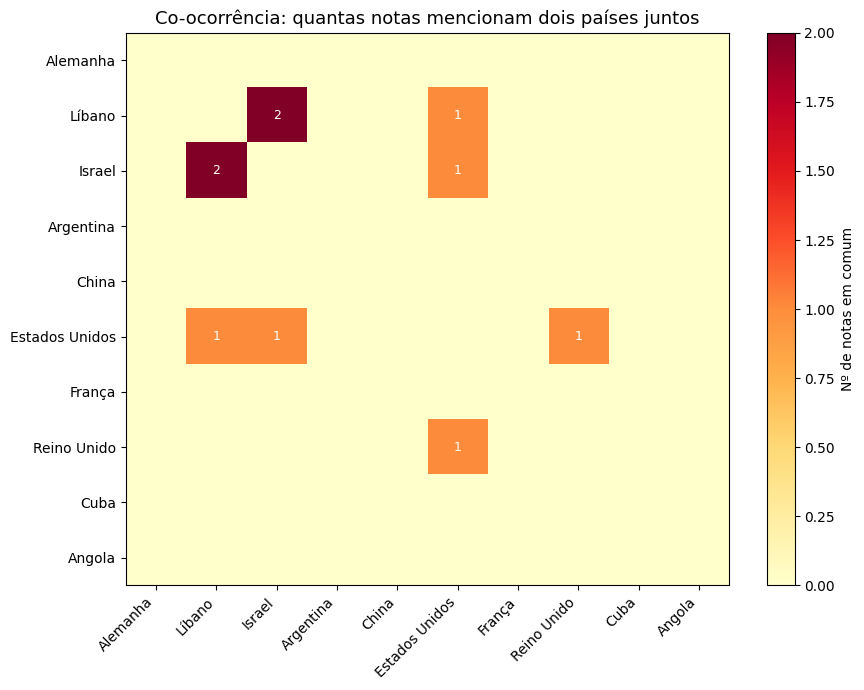

In [33]:
import numpy as np

paises_analise = ['Alemanha', 'Líbano', 'Israel', 'Argentina', 'China',
                  'Estados Unidos', 'França', 'Reino Unido', 'Cuba', 'Angola']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    pais: df['texto_completo'].str.contains(pais, case=False, na=False, regex=False).astype(int)
    for pais in paises_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(paises_analise)))
ax.set_yticks(range(len(paises_analise)))
ax.set_xticklabels(paises_analise, rotation=45, ha='right')
ax.set_yticklabels(paises_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam dois países juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(paises_analise)):
    for j in range(len(paises_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()


---

## 🎯 O que mais você pode fazer?

Algumas ideias para continuar explorando:

- **Extração de entidades nomeadas** (NER) com `spaCy` para encontrar países, pessoas e organizações automaticamente, sem ter que listar tudo na mão
- **Análise de sentimento** dos textos (uma nota é mais "neutra", "preocupada", "celebrativa"?)
- **Tópicos latentes** com LDA ou BERTopic para descobrir agrupamentos temáticos
- **Filtro interativo** com `ipywidgets` para o usuário digitar um termo e ver o resultado em tempo real
- **Salvar os gráficos** como PNG/PDF com `plt.savefig('nome.png', dpi=200, bbox_inches='tight')`
- **Exportar buscas** para Excel: `buscar_termo('Israel').to_excel('resultado.xlsx', index=False)`
